In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [159]:
df.shape

(10000, 3)

In [143]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

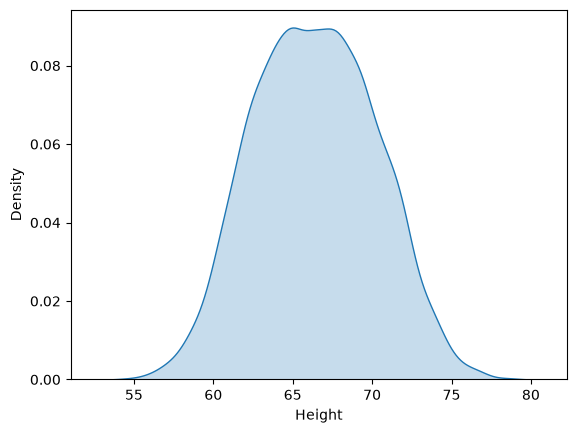

In [144]:
sns.kdeplot(df['Height'],fill=True)

<Axes: ylabel='Height'>

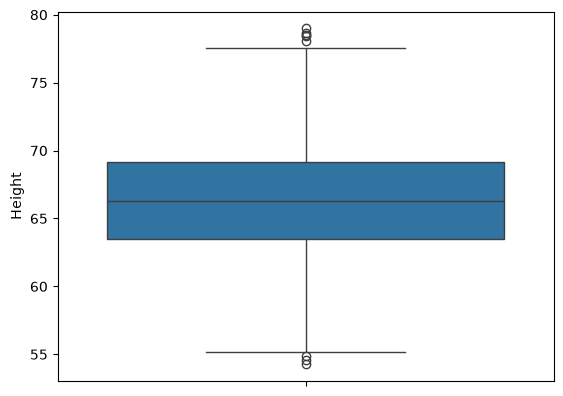

In [145]:
sns.boxplot(df['Height'])

In [146]:
# Maximum Limit
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [147]:
# Minimum Limit
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [148]:
# Outliers
df[(df['Height'] >= upper_limit)| (df['Height'] <= lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# Trimming

In [149]:
# Outliers Removed
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [150]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

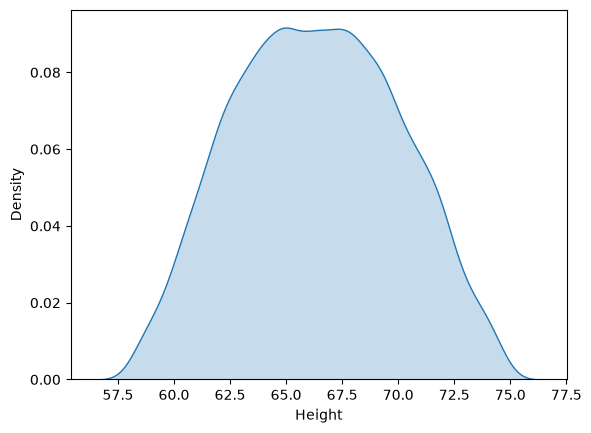

In [151]:
sns.kdeplot(new_df['Height'],fill=True)

<Axes: ylabel='Height'>

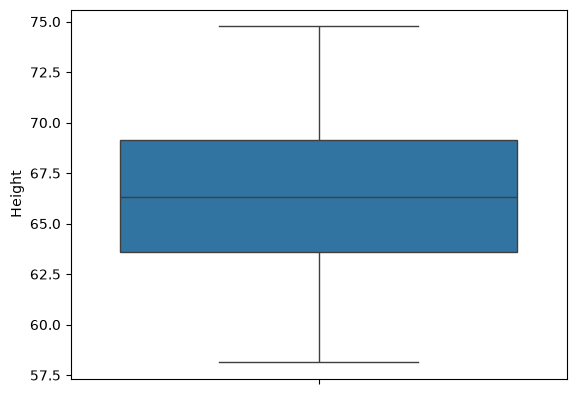

In [152]:
sns.boxplot(new_df['Height'])

# Capping (Winsorization)

In [160]:
# np.where(condition, value_if_true, value_if_false)
df['Height'] = np.where(df['Height']>=upper_limit,upper_limit,np.where(df['Height'] <= lower_limit,lower_limit,df['Height']))


In [161]:
df.shape

(10000, 3)

In [162]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

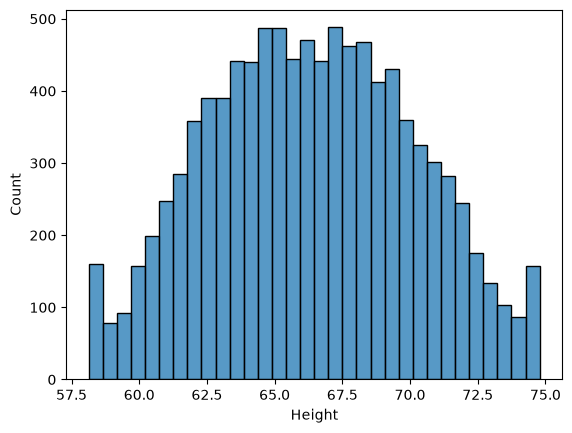

In [165]:
sns.histplot(df['Height'],fill=True)

<Axes: ylabel='Height'>

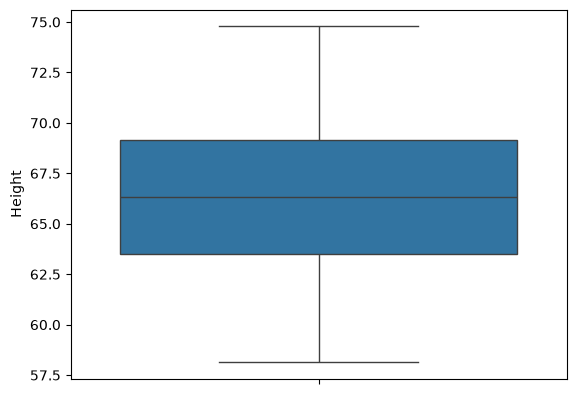

In [164]:
sns.boxplot(df['Height'])